In [ ]:
# @title
# importing kaggle competition dataset
# make sure to upload kaggle.json to google drive
competition_name = "optiver-realized-volatility-prediction"

# Mount your Google Drive.
from google.colab import drive
drive.mount("/content/drive")

kaggle_creds_path = "/content/drive/MyDrive/kaggle.json"

! pip install kaggle --quiet
! cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
! mkdir ~/.kaggle

! kaggle competitions download -c {competition_name}

! mkdir kaggle_data
! unzip {competition_name + ".zip"} -d kaggle_data

# Unmount your Google Drive
drive.flush_and_unmount()

### IGNORE THIS CELL

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(2026)
DATA_DIR = '/content/drive/MyDrive/TimeSeriesDeepLearning_FIM601/kaggle_data/optiver-realized-volatility-prediction'

Naive model

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
train = pd.read_csv('/content/drive/MyDrive/TimeSeriesDeepLearning_FIM601/kaggle_data/optiver-realized-volatility-prediction/train.csv')
train.head()

,stock_id,time_id,target
0,0,5,0.004136
1,0,11,0.001445
2,0,16,0.002168
3,0,31,0.002195
4,0,62,0.001747


In [4]:
import os
from sklearn.metrics import r2_score
import glob
list_order_book_file_train = glob.glob('/content/drive/MyDrive/TimeSeriesDeepLearning_FIM601/kaggle_data/optiver-realized-volatility-prediction/book_train.parquet/*')

In [5]:
def log_return(list_stock_prices):
    return np.log(list_stock_prices).diff()

def realized_volatility(series_log_return):
    return np.sqrt(np.sum(series_log_return**2))

In [6]:
def realized_volatility_per_time_id(file_path, prediction_column_name):
    df_book_data = pd.read_parquet(file_path)
    df_book_data['wap'] =(df_book_data['bid_price1'] * df_book_data['ask_size1']+df_book_data['ask_price1'] * df_book_data['bid_size1'])  / (
                                      df_book_data['bid_size1']+ df_book_data[
                                  'ask_size1'])
    df_book_data['log_return'] = df_book_data.groupby('time_id')['wap'].transform(log_return)
    df_book_data = df_book_data[~df_book_data['log_return'].isnull()]
    df_realized_vol_per_stock =  pd.DataFrame(df_book_data.groupby(['time_id'])['log_return'].agg(realized_volatility)).reset_index()
    df_realized_vol_per_stock = df_realized_vol_per_stock.rename(columns = {'log_return':prediction_column_name})
    stock_id = file_path.split('=')[1]
    df_realized_vol_per_stock['row_id'] = df_realized_vol_per_stock['time_id'].apply(lambda x:f'{stock_id}-{x}')
    return df_realized_vol_per_stock[['row_id',prediction_column_name]]

def past_realized_volatility_per_stock(list_file,prediction_column_name):
    df_past_realized = pd.DataFrame()
    for file in list_file:
        df_past_realized = pd.concat([df_past_realized,
                                     realized_volatility_per_time_id(file,prediction_column_name)])
    return df_past_realized
df_past_realized_train = past_realized_volatility_per_stock(list_file=list_order_book_file_train,
                                                           prediction_column_name='pred')

train['row_id'] = train['stock_id'].astype(str) + '-' + train['time_id'].astype(str)
train = train[['row_id','target']]
df_joined = train.merge(df_past_realized_train[['row_id','pred']], on = ['row_id'], how = 'left')

from sklearn.metrics import r2_score
def rmspe(y_true, y_pred):
    return  (np.sqrt(np.mean(np.square((y_true - y_pred) / y_true))))
R2 = round(r2_score(y_true = df_joined['target'], y_pred = df_joined['pred']),3)
RMSPE = round(rmspe(y_true = df_joined['target'], y_pred = df_joined['pred']),3)
print(f'Performance of the naive prediction: R2 score: {R2}, RMSPE: {RMSPE}')

Performance of the naive prediction: R2 score: 0.628, RMSPE: 0.341


### Mark: Below I am testing implementation with polars for more efficient data manipulation. We can translate pandas manipulation to polars pretty easily.

In [ ]:
import polars as pl

In [ ]:
pl_lazy_book_train = pl.scan_parquet(f'{DATA_DIR}/book_train.parquet', hive_partitioning=True)

In [ ]:
# checking book data schema
check_pl = pl.read_parquet_schema(f'{DATA_DIR}/book_train.parquet/stock_id=0/c439ef22282f412ba39e9137a3fdabac.parquet')
print(check_pl)

Schema({'time_id': Int16, 'seconds_in_bucket': Int16, 'bid_price1': Float32, 'ask_price1': Float32, 'bid_price2': Float32, 'ask_price2': Float32, 'bid_size1': Int32, 'ask_size1': Int32, 'bid_size2': Int32, 'ask_size2': Int32})


In [ ]:
# TRANSFORM: Define your preprocessing steps
# Polars builds an optimized query plan for these operations
processed_book = (
    pl_lazy_book_train
    # OPTIMIZATION: Convert stock_id to Int8 early to save memory
    .with_columns(pl.col("stock_id").cast(pl.Int8))
    # Ensure correct ordering for time-based calculations
    .sort(["stock_id", "time_id", "seconds_in_bucket"])

    .with_columns(
        # Calculate the primary WAP (Weighted Average Price)
        wap1 = ((pl.col("bid_price1") * pl.col("ask_size1") +
                pl.col("ask_price1") * pl.col("bid_size1")) /
                (pl.col("bid_size1") + pl.col("ask_size1"))).cast(pl.Float32),

        wap2 = ((pl.col("bid_price2") * pl.col("ask_size2") +
                pl.col("ask_price2") * pl.col("bid_size2")) /
                (pl.col("bid_size2") + pl.col("ask_size2"))).cast(pl.Float32),

        # Calculate the level 1 Bid-Ask spread
        spread1 = (pl.col("ask_price1") - pl.col("bid_price1")).cast(pl.Float32),

        # Calculate the level 1 and level 1&2 volume
        vol_l1 = (pl.col("bid_size1") + pl.col("ask_size1")),
        vol_l2 = (pl.col("bid_size2") + pl.col("ask_size2"))
    )
    .with_columns(
        # Calculate the total volume
        vol_total = (pl.col("vol_l1") + pl.col("vol_l2")),

        # Calculate the volume imbalance -> Float32
        vol_imbalance = ((pl.col("bid_size1") - pl.col("ask_size1")) /
                        (pl.col("bid_size1") + pl.col("ask_size1"))).cast(pl.Float32),

        wap_basis = (pl.col("wap1") - pl.col("wap2")).cast(pl.Float32)
    )

    # Time-Based Features
    .with_columns(
        # Create 60-second micro-buckets
        minute_in_bucket = (pl.col("seconds_in_bucket") // 60).cast(pl.Int8),

        # Calculate time elapsed since last update
        time_since_last_update = (
            pl.col("seconds_in_bucket") - pl.col("seconds_in_bucket")
            .shift(1)
            .over(["stock_id", "time_id"])
        ).fill_null(0).cast(pl.Int16)
    )

    # Lagged Variables
    .with_columns(
        # Tick-to-tick Log Return of WAP
        log_return_1t = (
            pl.col("wap1").log() - pl.col("wap1").shift(1).log()
        ).over(["stock_id", "time_id"]).fill_null(0).cast(pl.Float32),

        # Spread change
        spread_change = (
            pl.col("spread1") - pl.col("spread1").shift(1)
        ).over(["stock_id", "time_id"]).fill_null(0).cast(pl.Float32)
    )
    .with_columns(
        # Squared returns
        log_return_sq = (pl.col("log_return_1t") ** 2).cast(pl.Float32)
    )
    .with_columns(
        # Realized volatility
        realized_volatility = pl.col("log_return_sq").sum().sqrt().over(["stock_id", "time_id"]).cast(pl.Float32)
    )

    # Rolling window statistics
    .with_columns(
        # 10-tick rolling mean of spread
        spread_rolling_mean_10t = (
            pl.col("spread1")
            .rolling_mean(window_size=10, min_samples=1) # min_samples overides min tick count require for 10t statistics; addressing null values
            .over(["stock_id", "time_id"])
        ).cast(pl.Float32),

        # 20-tick rolling std of log returns
        volatility_rolling_20t = (
            pl.col("log_return_1t")
            .rolling_std(window_size=20, min_samples=2)
            .over(["stock_id", "time_id"])
        ).cast(pl.Float32),

        # Moving sum of order flow imbalance
        order_flow_imbalance_15t = (
            (pl.col("bid_size1") - pl.col("ask_size1"))
            .rolling_sum(window_size=15, min_samples=1)
            .over(["stock_id", "time_id"])
        ).cast(pl.Int32)
    )
)

In [ ]:
# Group by stock and time, then calculate summary statistics (e.g., standard deviation of WAP)
aggregated_features = (
    processed_book
    .group_by(["stock_id", "time_id"])
    .agg(
        # Example feature: Realized volatility (std dev of log returns or WAP variations)
        realized_volatility = pl.col("log_return_sq").sum().sqrt(),
        wap1_mean = pl.col("wap1").mean(),

        # Average spread over the time bucket
        mean_spread = pl.col("spread1").mean(),

        # Count the number of updates in this bucket
        update_count = pl.col("seconds_in_bucket").count(),

        # ---- Volume Features ----
        # vol_mean = pl.col("vol_total").mean(),
        # vol_std = pl.col("vol_total").std(),
        vol_sum = pl.col("vol_total").sum(),

        vol_90 = pl.col("vol_total").quantile(0.9),
        # vol_99 = pl.col("vol_total").quantile(0.99),

        vol_imbalance_mean = pl.col("vol_imbalance").mean(),
        vol_imbalance_std = pl.col("vol_imbalance").std()
    )
)

In [ ]:
processed_book_df = processed_book.collect()

print(processed_book_df.head())

shape: (5, 28)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ time_id ┆ seconds_in ┆ bid_price ┆ ask_price ┆ … ┆ realized_ ┆ spread_ro ┆ volatilit ┆ order_flo │
│ ---     ┆ _bucket    ┆ 1         ┆ 1         ┆   ┆ volatilit ┆ lling_mea ┆ y_rolling ┆ w_imbalan │
│ i16     ┆ ---        ┆ ---       ┆ ---       ┆   ┆ y         ┆ n_10t     ┆ _20t      ┆ ce_15t    │
│         ┆ i16        ┆ f32       ┆ f32       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│         ┆            ┆           ┆           ┆   ┆ f32       ┆ f32       ┆ f32       ┆ i32       │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 5       ┆ 0          ┆ 1.001422  ┆ 1.002301  ┆ … ┆ 0.004499  ┆ 0.000879  ┆ null      ┆ -223      │
│ 5       ┆ 1          ┆ 1.001422  ┆ 1.002301  ┆ … ┆ 0.004499  ┆ 0.000879  ┆ 0.00001   ┆ -320      │
│ 5       ┆ 5          ┆ 1.001422  ┆ 1.002301  ┆ … ┆ 0.004499  ┆ 0.000879  ┆

In [ ]:
with pl.Config(tbl_cols=-1): # Set context to show all columns
    # check null values
    null_count_df = processed_book_df.null_count()
    print(null_count_df)

shape: (1, 28)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ tim ┆ sec ┆ bid ┆ ask ┆ bid ┆ ask ┆ bid ┆ ask ┆ bid ┆ ask ┆ sto ┆ wap ┆ wap ┆ spr ┆ vol ┆ vol ┆ vol ┆ vol ┆ wap ┆ min ┆ tim ┆ log ┆ spr ┆ log ┆ rea ┆ spr ┆ vol ┆ ord │
│ e_i ┆ ond ┆ _pr ┆ _pr ┆ _pr ┆ _pr ┆ _si ┆ _si ┆ _si ┆ _si ┆ ck_ ┆ 1   ┆ 2   ┆ ead ┆ _l1 ┆ _l2 ┆ _to ┆ _im ┆ _ba ┆ ute ┆ e_s ┆ _re ┆ ead ┆ _re ┆ liz ┆ ead ┆ ati ┆ er_ │
│ d   ┆ s_i ┆ ice ┆ ice ┆ ice ┆ ice ┆ ze1 ┆ ze1 ┆ ze2 ┆ ze2 ┆ id  ┆ --- ┆ --- ┆ 1   ┆ --- ┆ --- ┆ tal ┆ bal ┆ sis ┆ _in ┆ inc ┆ tur ┆ _ch ┆ tur ┆ ed_ ┆ _ro ┆ lit ┆ flo │
│ --- ┆ n_b ┆ 1   ┆ 1   ┆ 2   ┆ 2   ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ u32 ┆ u32 ┆ --- ┆ u32 ┆ u32 ┆ --- ┆ anc ┆ --- ┆ _bu ┆ e_l ┆ n_1 ┆ ang ┆ n_s ┆ vol ┆ lli ┆ y_r ┆ w_i │
│ u32 ┆ uck ┆ --- ┆ --- ┆ --- ┆ --- ┆ u32 ┆ u32 ┆ u32 ┆ u32 ┆ u32 ┆     ┆     ┆ u32 ┆     ┆     ┆ u32 ┆ e   ┆ u32 ┆ cke ┆ ast ┆ t   ┆ e

In [ ]:
# Finally, execute the lazy computation and load the aggregated result into memory
aggregated_df = aggregated_features.collect()

print(aggregated_df.head())

shape: (5, 10)
┌──────────┬─────────┬──────────────┬───────────┬───┬─────────┬────────┬─────────────┬─────────────┐
│ stock_id ┆ time_id ┆ realized_vol ┆ wap1_mean ┆ … ┆ vol_sum ┆ vol_90 ┆ vol_imbalan ┆ vol_imbalan │
│ ---      ┆ ---     ┆ atility      ┆ ---       ┆   ┆ ---     ┆ ---    ┆ ce_mean     ┆ ce_std      │
│ i8       ┆ i16     ┆ ---          ┆ f32       ┆   ┆ i32     ┆ f64    ┆ ---         ┆ ---         │
│          ┆         ┆ f32          ┆           ┆   ┆         ┆        ┆ f32         ┆ f32         │
╞══════════╪═════════╪══════════════╪═══════════╪═══╪═════════╪════════╪═════════════╪═════════════╡
│ 110      ┆ 16320   ┆ 0.002114     ┆ 1.000985  ┆ … ┆ 60790   ┆ 584.0  ┆ -0.289477   ┆ 0.630084    │
│ 37       ┆ 6287    ┆ 0.003535     ┆ 0.99944   ┆ … ┆ 24874   ┆ 348.0  ┆ -0.369165   ┆ 0.595235    │
│ 85       ┆ 17707   ┆ 0.000985     ┆ 1.000328  ┆ … ┆ 1093801 ┆ 3471.0 ┆ 0.121137    ┆ 0.457652    │
│ 69       ┆ 18940   ┆ 0.000815     ┆ 1.000277  ┆ … ┆ 1730509 ┆ 3871.0 ┆ 0.0

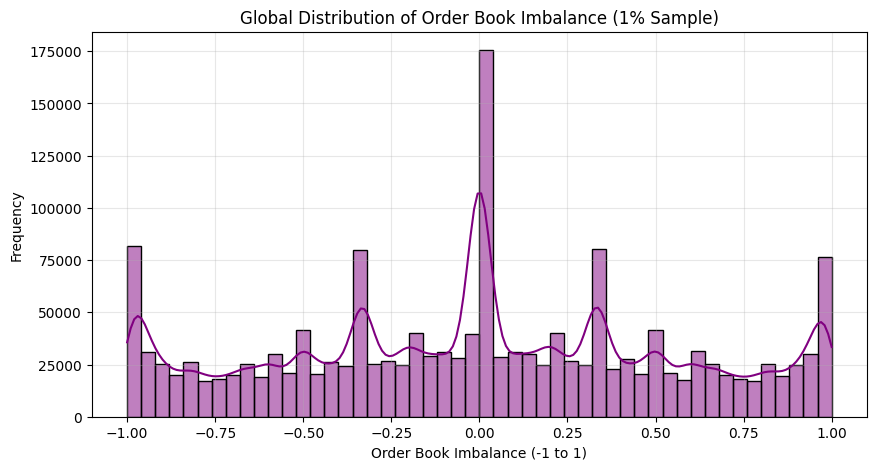

In [ ]:
df_sample = (
    processed_book
    .select(["spread1", "vol_total", "vol_imbalance"])
    .collect()
    .sample(fraction=0.01, seed=42) # Adjust fraction based on your RAM
)

# Plotting the global distribution of the Order Book Imbalance
plt.figure(figsize=(10, 5))
sns.histplot(df_sample['vol_imbalance'].to_numpy(), bins=50, kde=True, color='purple')
plt.title('Global Distribution of Order Book Imbalance (1% Sample)')
plt.xlabel('Order Book Imbalance (-1 to 1)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

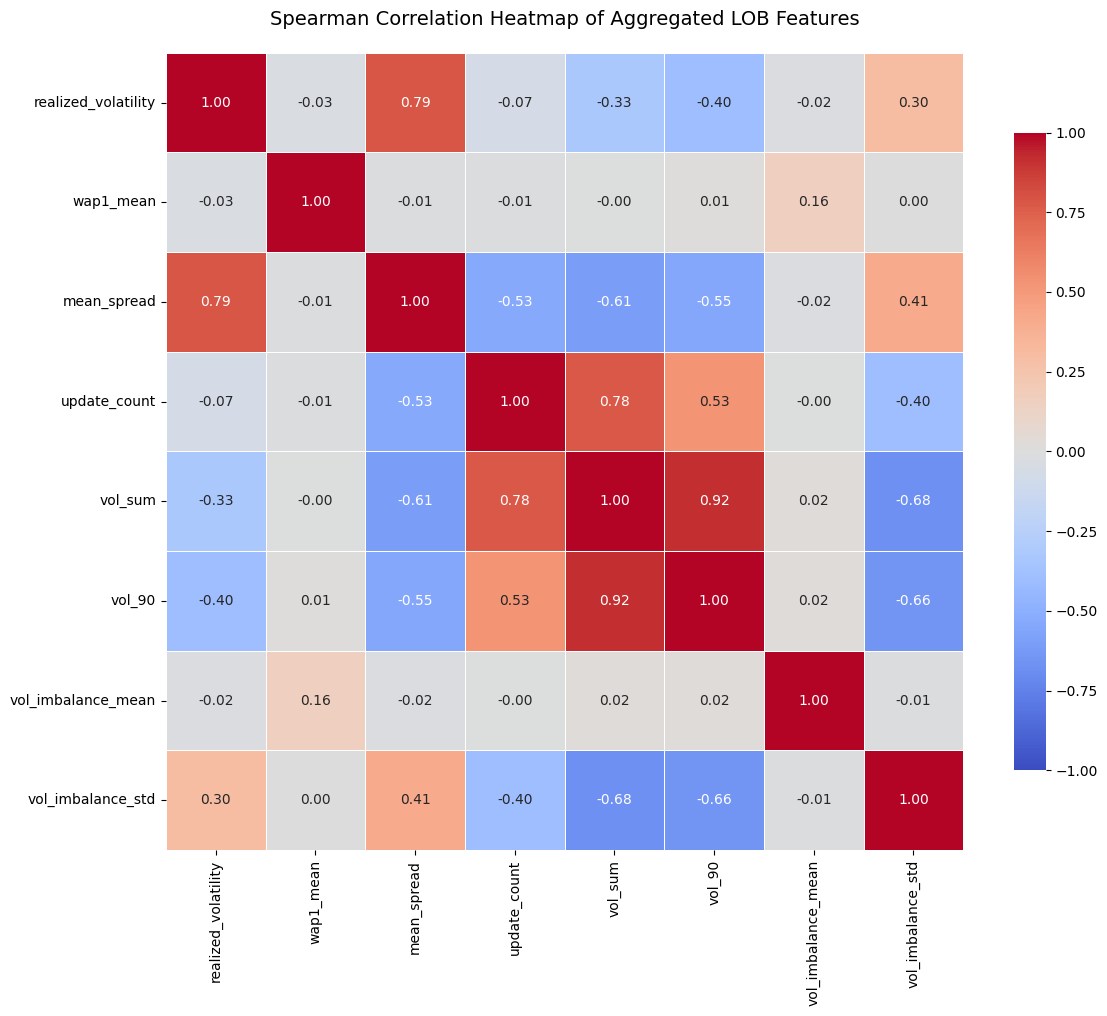

In [ ]:
# Spearman rank correlation Heat map
# Exclude identifiers (we don't want to correlate stock_id or time_id)
df_numeric = aggregated_features.drop(["stock_id", "time_id"])

# Convert to Pandas and calculate the Spearman correlation matrix
# Seaborn natively understands Pandas DataFrames best for index/column labeling
corr_matrix = (df_numeric.collect()).to_pandas().corr(method='spearman')

# Visualize the Heatmap
plt.figure(figsize=(12, 10))

# Create the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,          # Display the correlation coefficients
    fmt=".2f",           # Round to 2 decimal places
    cmap="coolwarm",     # Red for positive correlation, Blue for negative
    vmin=-1, vmax=1,     # Fix the scale from -1 to 1
    center=0,            # Center the colormap at 0
    square=True,         # Make the grid cells square
    linewidths=.5,       # Add lines between cells for readability
    cbar_kws={"shrink": .8} # Shrink the colorbar slightly
)

plt.title("Spearman Correlation Heatmap of Aggregated LOB Features", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

#### Time Series Based Feature Engineering with Polars
Before applying any time-dependent transformations, you must ensure the data is strictly sorted chronologically. If the rows are out of order, your lags and rolling windows will be corrupted.

#### Time-Based Features
Because `seconds_in_bucket` resets to 0 for every `time_id`, it acts as our temporal axis. We can derive features that help a Transformer understand where it is within the 600-second window.

In [ ]:
time_features = processed_book.with_columns(
    # Create 60-second micro-buckets (values 0 through 9)
    # This helps models capture structural behaviors, like end-of-bucket trading spikes
    minute_in_bucket = (pl.col("seconds_in_bucket") // 60).cast(pl.Int8),

    # Calculate the time elapsed since the last order book update
    # We fill the first null value in each bucket with 0
    time_since_last_update = (
        pl.col("seconds_in_bucket")
        - pl.col("seconds_in_bucket").shift(1)
    ).over(["stock_id", "time_id"]).fill_null(0)
)

 #### Lagged Variables
Lagging allows the model to look at the recent past to calculate differentials, such as returns or changes in the bid-ask spread. We use `.shift()` combined with `.over()` to enforce our boundaries.

In [ ]:
lagged_features = (
      time_features.with_columns(
      # Calculate the tick-to-tick Log Return of the Weighted Average Price
      log_return_1t = (
          pl.col("wap1").log() - pl.col("wap1").shift(1).log()
      ).over(["stock_id", "time_id"]),

      # Calculate how much the spread widened or narrowed since the last update
      spread_change = (
          pl.col("spread1") - pl.col("spread1").shift(1)
      ).over(["stock_id", "time_id"])
  ).fill_null(0) # The first return in a bucket is 0
  .with_columns(
        # Calculate squared returns
        log_return_sq=pl.col("log_return") ** 2
    )
    .with_columns(
        # Calculate expanding realized volatility
        realized_volatility=pl.col("log_return_sq").cum_sum().sqrt().over("time_id")
    )
)

#### Moving Window Statistics
Because order book updates arrive irregularly, you have two choices for rolling windows: tick-based (number of rows) or time-based (number of seconds). <br>
Here is how to calculate tick-based rolling statistics using `.rolling_mean()` and `.rolling_std()`. These will calculate metrics over the last $N$ updates, regardless of how much time passed between them.

In [ ]:
rolling_features = lagged_features.with_columns(
    # 10-tick rolling mean of the bid-ask spread
    spread_rolling_mean_10t = (
        pl.col("spread1")
        .rolling_mean(window_size=10)
        .over(["stock_id", "time_id"])
    ),

    # 20-tick rolling standard deviation of log returns (Realized Micro-Volatility)
    # We use a min_periods of 2 so it starts calculating before reaching 20 ticks
    volatility_rolling_20t = (
        pl.col("log_return_1t")
        .rolling_std(window_size=20)
        .over(["stock_id", "time_id"])
    ),

    # Moving sum of order flow imbalance over the last 15 updates
    order_flow_imbalance_15t = (
        (pl.col("bid_size1") - pl.col("ask_size1"))
        .rolling_sum(window_size=15)
        .over(["stock_id", "time_id"])
    )
)


In [ ]:
# taking a look at a particular stock
target_stock = 0
target_time_id = 100

df_subset_book = (
    processed_book_df
    .filter((pl.col("stock_id") == target_stock) & (pl.col("time_id") < target_time_id))
)
df_subset_book

time_id,seconds_in_bucket,bid_price1,ask_price1,bid_price2,ask_price2,bid_size1,ask_size1,bid_size2,ask_size2,stock_id,wap1,wap2,spread1,vol_l1,vol_l2,vol_total,vol_imbalance,wap_basis,minute_in_bucket,time_since_last_update,log_return_1t,spread_change,log_return_sq,realized_volatility,spread_rolling_mean_10t,volatility_rolling_20t,order_flow_imbalance_15t
i16,i16,f32,f32,f32,f32,i32,i32,i32,i32,i8,f32,f32,f32,i32,i32,i32,f32,f32,i8,i16,f32,f32,f32,f32,f32,f32,i32
5,0,1.001422,1.002301,1.00137,1.002353,3,226,2,100,0,1.001434,1.00139,0.000879,229,102,331,-0.973799,0.000044,0,0,0.0,0.0,0.0,0.004499,0.000879,null,-223
5,1,1.001422,1.002301,1.00137,1.002353,3,100,2,100,0,1.001448,1.00139,0.000879,103,102,205,-0.941748,0.000058,0,1,0.000014,0.0,1.9730e-10,0.004499,0.000879,0.00001,-320
5,5,1.001422,1.002301,1.00137,1.002405,3,100,2,100,0,1.001448,1.001391,0.000879,103,102,205,-0.941748,0.000057,0,4,0.0,0.0,0.0,0.004499,0.000879,0.000008,-417
5,6,1.001422,1.002301,1.00137,1.002405,3,126,2,100,0,1.001443,1.001391,0.000879,129,102,231,-0.953488,0.000052,0,1,-0.000005,0.0,2.6201e-11,0.004499,0.000879,0.000008,-540
5,7,1.001422,1.002301,1.00137,1.002405,3,126,2,100,0,1.001443,1.001391,0.000879,129,102,231,-0.953488,0.000052,0,1,0.0,0.0,0.0,0.004499,0.000879,0.000007,-663
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
97,590,0.997479,0.998294,0.996868,0.998854,100,188,41,128,0,0.997762,0.99735,0.000815,288,169,457,-0.305556,0.000412,9,1,-0.000125,0.0,1.5571e-8,0.010033,0.001401,0.000348,43
97,591,0.996919,0.998294,0.996868,0.998854,200,88,41,128,0,0.997874,0.99735,0.001375,288,169,457,0.388889,0.000524,9,1,0.000112,0.00056,1.2545e-8,0.010033,0.001329,0.000336,-18
97,592,0.996919,0.998854,0.996868,0.999465,200,28,41,200,0,0.998616,0.99731,0.001935,228,241,469,0.754386,0.001307,9,1,0.000744,0.00056,5.5359e-7,0.010033,0.001319,0.000382,169


In [ ]:
df_trade = pl.scan_parquet(f'{DATA_DIR}/trade_train.parquet', hive_partitioning=True)

df_trade_adv = (
    df_trade
    .sort(["stock_id", "time_id", "seconds_in_bucket"])
    .with_columns(
        # 1. Inter-Arrival Time (Seconds since the last trade in this bucket)
        inter_arrival_time=pl.col("seconds_in_bucket").diff().over(["stock_id", "time_id"]).fill_null(0),

        # 2. Average Trade Size (Institutional vs. Retail proxy)
        avg_trade_size=(pl.col("size") / pl.col("order_count"))
    )
)
trade_df = df_trade_adv.collect()
trade_df

time_id,seconds_in_bucket,price,size,order_count,stock_id,inter_arrival_time,avg_trade_size
i16,i16,f32,i32,i16,i64,i16,f64
5,21,1.002301,326,12,0,0,27.166667
5,46,1.002778,128,4,0,25,32.0
5,50,1.002818,55,1,0,4,55.0
5,57,1.003155,121,5,0,7,24.2
5,68,1.003646,4,1,0,11,4.0
…,…,…,…,…,…,…,…
32767,549,0.999949,100,2,126,53,50.0
32767,551,0.999691,145,3,126,2,48.333333
32767,571,0.99964,1,1,126,20,1.0


In [ ]:
target_stock = 5
target_time_id = 100

df_subset_trade = (
    trade_df
    .filter((pl.col("stock_id") == target_stock) & (pl.col("time_id") < target_time_id))
)
df_subset_trade

time_id,seconds_in_bucket,price,size,order_count,stock_id,inter_arrival_time,avg_trade_size
i16,i16,f32,i32,i16,i64,i16,f64
5,11,1.001091,3,2,5,0,1.5
5,14,1.001395,6,4,5,3,1.5
5,15,1.001639,2,2,5,1,1.0
5,25,1.001375,1,1,5,10,1.0
5,31,1.00128,2,1,5,6,2.0
…,…,…,…,…,…,…,…
97,492,0.99283,320,9,5,19,35.555556
97,504,0.993636,2,1,5,12,2.0
97,547,0.995539,402,13,5,43,30.923077


In [ ]:
import hvplot.polars
df_subset_trade.hvplot.scatter(
    x="seconds_in_bucket",
    y="price",
    by="time_id",
    width=650,
    title="Executed Trade",
    xlabel='seconds_in_bucket',
    ylabel='price',
)

:NdOverlay   [time_id]
   :Scatter   [seconds_in_bucket]   (price)

In [ ]:
# loading the whole dataset
# df_book_train_raw = pd.read_parquet(f'{DATA_DIR}/book_train.parquet')
# df_book_test_raw = pd.read_parquet(f'{DATA_DIR}/book_test.parquet')

# df_trade_train_raw = pd.read_parquet(f'{DATA_DIR}/trade_train.parquet')
# df_trade_test_raw = pd.read_parquet(f'{DATA_DIR}/trade_test.parquet')

df_train_raw = pd.read_csv(f'{DATA_DIR}/train.csv')
df_test_raw = pd.read_csv(f'{DATA_DIR}/test.csv')

In [ ]:
# display(df_train_raw.head(5))
# display(df_test_raw.head(5))
display(df_book_train_raw.head(5))
display(df_trade_train_raw.head(5))

In [ ]:
# loading order book data by single stock
df_book_train_stock_id_0 = pd.read_parquet(f'{DATA_DIR}/book_train.parquet/stock_id=0')
display(df_book_train_stock_id_0.head(5))

,time_id,seconds_in_bucket,bid_price1,ask_price1,bid_price2,ask_price2,bid_size1,ask_size1,bid_size2,ask_size2
0,5,0,1.001422,1.002301,1.00137,1.002353,3,226,2,100
1,5,1,1.001422,1.002301,1.00137,1.002353,3,100,2,100
2,5,5,1.001422,1.002301,1.00137,1.002405,3,100,2,100
3,5,6,1.001422,1.002301,1.00137,1.002405,3,126,2,100
4,5,7,1.001422,1.002301,1.00137,1.002405,3,126,2,100


We can start by implementing the EDA functions on a single stock for now

In [ ]:
df_book_train_stock_id_0.isna().sum()

,0
time_id,0
seconds_in_bucket,0
bid_price1,0
ask_price1,0
bid_price2,0
ask_price2,0
bid_size1,0
ask_size1,0
bid_size2,0
ask_size2,0


In [ ]:
df_book_train_stock_id_0['bid_volume'] = df_book_train_stock_id_0[['bid_size1', 'bid_size2']].sum(axis=1)
df_book_train_stock_id_0['ask_volume'] = df_book_train_stock_id_0[['ask_price1', 'ask_price2']].sum(axis=1)
df_book_train_stock_id_0['total_volume'] = df_book_train_stock_id_0['bid_volume'] + df_book_train_stock_id_0['ask_volume']

In [ ]:
df_book_train_stock_id_0[['bid_volume', 'ask_volume', 'total_volume']].describe()

,bid_volume,ask_volume,total_volume
count,917553.000000,917553.000000,917553.000000
mean,200.487343,2.001253,202.488596
std,141.745505,0.007432,141.746100
min,2.000000,1.888793,3.954726
25%,104.000000,1.998619,106.000457
50%,194.000000,2.000829,196.006198
75%,290.000000,2.003301,291.999202
max,4491.000000,2.114027,4493.010052


In [ ]:
df_book_train_stock_id_0.groupby('time_id')['total_volume'].describe()

,count,mean,std,min,25%,50%,75%,max
time_id,,,,,,,,
5,302.0,161.154184,112.361280,4.006309,103.008895,136.008791,206.259464,642.008533
11,200.0,247.410946,117.043046,17.000904,203.000891,260.001204,326.750452,510.000703
16,188.0,212.659630,109.302608,8.996075,131.001723,202.001005,289.751137,458.000431
31,120.0,185.240384,95.675036,25.999028,126.999028,155.998612,248.997502,451.998011
62,176.0,209.664490,96.643145,3.999487,107.000455,203.999814,293.000035,437.999907
...,...,...,...,...,...,...,...,...
32751,297.0,174.414071,147.915823,4.994277,21.997347,131.996826,310.997763,542.997659
32753,206.0,272.448141,194.481026,4.002503,106.000113,283.501977,402.002803,970.002203
32758,188.0,140.249800,87.317906,5.999143,104.001310,120.000932,201.998224,526.999345
